## Improved Prediction of Parkinson’s Disease Medication Needs Through Nested Conformal Prediction

STAGE 1: Binary Classification + Venn-Abers
Training: 3907, VA Calibration: 977, Test: 1221
[0]	validation-auc:0.84198
[100]	validation-auc:0.93979
[200]	validation-auc:0.94892
[300]	validation-auc:0.95280
[321]	validation-auc:0.95311

VA predictions for 6105 patients
Uncertainty - Mean: 0.008, Std: 0.016
Uncertainty - Min: 0.000, Max: 0.121

FILTERING: By Probability (Like Paper)
Filtered by p_lower > 0.5
Patients: 1177 / 6105 (19.3%)

Uncertainty in filtered set:
  Mean: 0.033
  Std: 0.022
  Min: 0.015
  Max: 0.121

STAGE 2: Split Filtered Patients
Training: 941, Test: 236
Mean LEDD change: 0.037
Base Model RMSE: 0.2161

ANALYSIS 1: BASELINE (Standard Conformal - No VA in Stage 2)


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


  naive               : Coverage=0.6229, Width=0.0389


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


  cv_plus             : Coverage=0.8475, Width=0.1331


...

      Coverage=0.6481, Width=0.2315
    low: 401 train, 108 test


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


      Coverage=0.6944, Width=0.1876
    high: 309 train, 74 test


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


      Coverage=0.6081, Width=0.3393
    OVERALL: Coverage=0.6568, Width=0.2452

  Running Weighted naive...
    Conformity score: 0.0193
    Coverage=0.6398, Width=0.0399

  Running Weighted cv_plus...
    Conformity score: 0.0193
    Coverage=0.6398, Width=0.0399

  Running Weighted jackknife_plus_ab...
    Conformity score: 0.0193
    Coverage=0.6398, Width=0.0399

COMPREHENSIVE COMPARISON

NAIVE
----------------------------------------------------------------------
  Baseline (No VA):    Cov=0.6229, Width=0.0389
  Stratified (VA bins): Cov=0.5593, Width=0.0393 (+1.0%)
    medium  : Cov=0.5556, Width=0.0381
    low     : Cov=0.5741, Width=0.0273
    high    : Cov=0.5405, Width=0.0577
  Weighted (VA-aware):  Cov=0.6398, Width=0.0399 (+2.5%)

CV_PLUS
----------------------------------------------------------------------
  Baseline (No VA):    Cov=0.8475, Width=0.1331
  Stratified (VA bins): Cov=0.8136, Width=0.3006 (+125.8%)
    medium  : Cov=0.8148, Width=0.2054
    low     : Cov=0.83

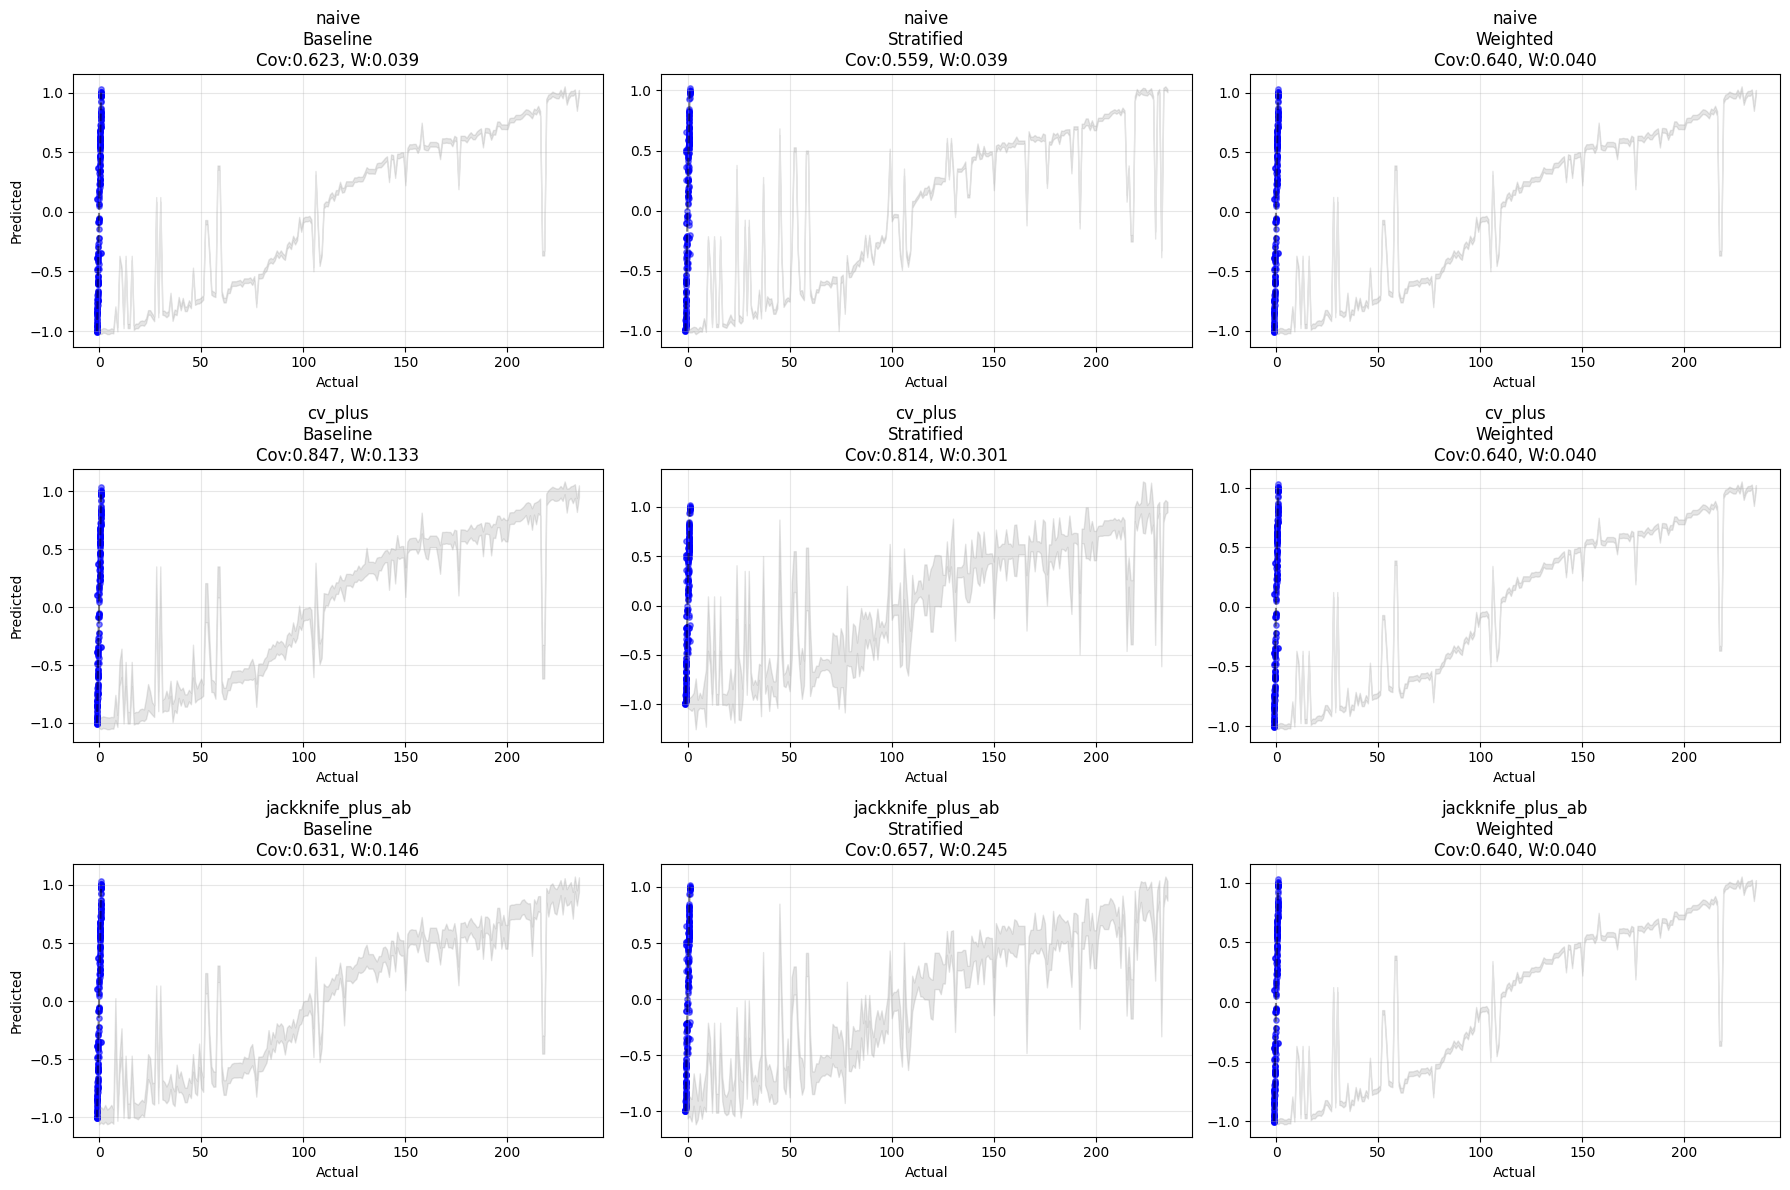


Done!


In [4]:
"""
Cascade Uncertainty Quantification: 
Show how Stage 1 VA uncertainty propagates to Stage 2 predictions

Key Idea: Patients with different Stage 1 uncertainty should get 
different Stage 2 treatment (wider/narrower intervals)
"""

import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from venn_abers import VennAbers

from mapie.regression import MapieRegressor
from mapie.metrics import regression_coverage_score, regression_mean_width_score
from mapie.subsample import Subsample

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# ============================================================
# SETUP (Same as before)
# ============================================================

path = 'data/data_1Y.csv'
data = pd.read_csv(path)
normalized_pctg_change = data['normalized_percent_change']
data.drop(columns=['normalized_percent_change'], inplace=True)

xgboost_df = data.copy()
demographic_vars = ['gender_source_value', 'race_source_value', 'ethnicity_source_value']
xgboost_df = pd.get_dummies(xgboost_df, columns=demographic_vars)

scaler = MinMaxScaler()
numeric_vars = ['mean_led_per_visit', 'age', 'length_of_stay', 
                'days_since_last_visit', 'days_to_diagnosis']
for var in numeric_vars:
    xgboost_df[var] = scaler.fit_transform(xgboost_df[[var]])

prediction_to_last = xgboost_df.pop('prediction')
xgboost_df['prediction'] = prediction_to_last

X = xgboost_df.iloc[:, :-1]
y_binary = xgboost_df.iloc[:, -1]
y_continuous = normalized_pctg_change

random_state = 21

# ============================================================
# STAGE 1: BINARY CLASSIFICATION + VENN-ABERS
# ============================================================

print("="*70)
print("STAGE 1: Binary Classification + Venn-Abers")
print("="*70)

X_train_stage1, X_test_stage1, y_train_binary, y_test_binary = train_test_split(
    X, y_binary, test_size=0.2, random_state=random_state
)

X_train_proper, X_cal, y_train_proper, y_cal_binary = train_test_split(
    X_train_stage1, y_train_binary, test_size=0.2, random_state=random_state
)

print(f"Training: {len(X_train_proper)}, VA Calibration: {len(X_cal)}, Test: {len(X_test_stage1)}")

# Train XGBoost
best_params = {
    "eval_metric": "auc", "objective": "binary:logistic",
    'sampling_method': 'gradient_based', 'alpha': 0.1, 'lambda': 1,
    'learning_rate': 0.1, 'max_depth': 7, 'tree_method': 'hist', 'device': "cuda",
}

d_train_proper = xgb.DMatrix(X_train_proper, label=y_train_proper)
d_cal = xgb.DMatrix(X_cal, label=y_cal_binary)

model_stage1 = xgb.train(best_params, d_train_proper, num_boost_round=700,
                         evals=[(d_cal, "validation")], verbose_eval=100,
                         early_stopping_rounds=10)

# Venn-Abers calibration
p_cal_uncalibrated = model_stage1.predict(d_cal, 
                     iteration_range=(0, model_stage1.best_iteration + 1))
p_cal_2d = np.column_stack([1 - p_cal_uncalibrated, p_cal_uncalibrated])

va = VennAbers()
va.fit(p_cal_2d, y_cal_binary.values)

# Get VA predictions for ALL patients
d_all = xgb.DMatrix(X)
p_all_uncalibrated = model_stage1.predict(d_all, 
                     iteration_range=(0, model_stage1.best_iteration + 1))
p_all_2d = np.column_stack([1 - p_all_uncalibrated, p_all_uncalibrated])

p_lower_all_2d, p_upper_all_2d = va.predict_proba(p_all_2d)
p_lower_all = p_lower_all_2d[:, 1]
p_upper_all = p_upper_all_2d[:, 1]
p_mid_all = (p_lower_all + p_upper_all) / 2
va_uncertainty_all = p_upper_all - p_lower_all

print(f"\nVA predictions for {len(X)} patients")
print(f"Uncertainty - Mean: {va_uncertainty_all.mean():.3f}, Std: {va_uncertainty_all.std():.3f}")
print(f"Uncertainty - Min: {va_uncertainty_all.min():.3f}, Max: {va_uncertainty_all.max():.3f}")

# ============================================================
# FILTERING: By Probability Only (Like Your Paper)
# ============================================================

print("\n" + "="*70)
print("FILTERING: By Probability (Like Paper)")
print("="*70)

# Filter by probability threshold ONLY (no uncertainty filter yet)
PROBABILITY_THRESHOLD = 0.5

mask_filtered = (p_lower_all > PROBABILITY_THRESHOLD)

X_filtered = X[mask_filtered]
y_filtered = y_continuous[mask_filtered]
p_lower_filtered = p_lower_all[mask_filtered]
p_upper_filtered = p_upper_all[mask_filtered]
va_uncertainty_filtered = va_uncertainty_all[mask_filtered]

print(f"Filtered by p_lower > {PROBABILITY_THRESHOLD}")
print(f"Patients: {len(X_filtered)} / {len(X)} ({len(X_filtered)/len(X)*100:.1f}%)")
print(f"\nUncertainty in filtered set:")
print(f"  Mean: {va_uncertainty_filtered.mean():.3f}")
print(f"  Std: {va_uncertainty_filtered.std():.3f}")
print(f"  Min: {va_uncertainty_filtered.min():.3f}")
print(f"  Max: {va_uncertainty_filtered.max():.3f}")

# ============================================================
# STAGE 2: SPLIT FILTERED PATIENTS
# ============================================================

print("\n" + "="*70)
print("STAGE 2: Split Filtered Patients")
print("="*70)

X_train_2, X_test_2, y_train_2, y_test_2, \
va_unc_train_2, va_unc_test_2, \
p_lower_train_2, p_lower_test_2 = train_test_split(
    X_filtered, y_filtered,
    va_uncertainty_filtered,
    p_lower_filtered,
    test_size=0.2, random_state=random_state
)

print(f"Training: {len(X_train_2)}, Test: {len(X_test_2)}")
print(f"Mean LEDD change: {y_train_2.mean():.3f}")

# Train base regression model
regression_params = {
    'alpha': 0.1, 'lambda': 1, 'learning_rate': 0.1, 'max_depth': 7,
    'n_estimators': 700, "eval_metric": 'rmse', 'objective': 'reg:squarederror',
    'sampling_method': 'gradient_based', 'tree_method': 'hist', 'device': "cuda"
}

xgb_model_base = xgb.XGBRegressor(**regression_params, random_state=random_state)
xgb_model_base.fit(X_train_2, y_train_2)

y_pred_base = xgb_model_base.predict(X_test_2)
rmse = np.sqrt(mean_squared_error(y_test_2, y_pred_base))
print(f"Base Model RMSE: {rmse:.4f}")

# ============================================================
# CONFORMAL STRATEGIES
# ============================================================

STRATEGIES = {
    "naive": {"method": "naive"},
    "cv_plus": {"method": "plus", "cv": 10},
    "jackknife_plus_ab": {"method": "plus", "cv": Subsample(n_resamplings=50)},
}
alpha = 0.2

# ============================================================
# ANALYSIS 1: BASELINE (No VA info in Stage 2)
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 1: BASELINE (Standard Conformal - No VA in Stage 2)")
print("="*70)

results_baseline = {}

for strategy, params in STRATEGIES.items():
    mapie = MapieRegressor(xgb_model_base, test_size=0.2, **params, 
                          random_state=random_state)
    mapie.fit(X_train_2, y_train_2)
    y_pred, y_pis = mapie.predict(X_test_2, alpha=alpha)
    
    coverage = regression_coverage_score(y_test_2, y_pis[:, 0, 0], y_pis[:, 1, 0])
    width = regression_mean_width_score(y_pis[:, 0, 0], y_pis[:, 1, 0])
    
    results_baseline[strategy] = {
        'y_pred': y_pred,
        'y_pis': y_pis,
        'coverage': coverage,
        'width': width
    }
    
    print(f"  {strategy:20s}: Coverage={coverage:.4f}, Width={width:.4f}")

# ============================================================
# ANALYSIS 2: UNCERTAINTY STRATIFICATION
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 2: CASCADE UNCERTAINTY (Stratified by VA Uncertainty)")
print("="*70)

# Create uncertainty bins
try:
    bins_train = pd.qcut(va_unc_train_2, q=3, labels=['low', 'medium', 'high'], 
                        duplicates='drop')
    bins_test = pd.qcut(va_unc_test_2, q=3, labels=['low', 'medium', 'high'], 
                       duplicates='drop')
    n_bins = 3
except ValueError:
    print("Cannot create 3 bins, using 2 bins")
    bins_train = pd.qcut(va_unc_train_2, q=2, labels=['low', 'high'], 
                        duplicates='drop')
    bins_test = pd.qcut(va_unc_test_2, q=2, labels=['low', 'high'], 
                       duplicates='drop')
    n_bins = 2

# Show distribution
print(f"\nUncertainty Stratification ({n_bins} bins):")
print("Training set:")
print(bins_train.value_counts().sort_index())
print("\nTest set:")
print(bins_test.value_counts().sort_index())

# For each bin, show the uncertainty range
for category in bins_train.unique():
    mask = (bins_train == category)
    unc_range = va_unc_train_2[mask]
    print(f"\n{category.upper()} uncertainty: [{unc_range.min():.3f}, {unc_range.max():.3f}], "
          f"Mean={unc_range.mean():.3f}")

results_stratified = {}

for strategy, params in STRATEGIES.items():
    print(f"\n  Running Stratified {strategy}...")
    
    y_pred_all = np.zeros(len(X_test_2))
    y_lower_all = np.zeros(len(X_test_2))
    y_upper_all = np.zeros(len(X_test_2))
    
    results_by_bin = {}
    
    for category in bins_train.unique():
        mask_train = (bins_train == category)
        mask_test = (bins_test == category)
        
        n_train_cat = mask_train.sum()
        n_test_cat = mask_test.sum()
        
        if n_train_cat < 10 or n_test_cat < 2:
            print(f"    {category}: Skipping (too few samples)")
            continue
        
        print(f"    {category}: {n_train_cat} train, {n_test_cat} test")
        
        # Get data for this uncertainty bin
        X_train_cat = X_train_2[mask_train]
        y_train_cat = y_train_2[mask_train]
        X_test_cat = X_test_2[mask_test]
        y_test_cat = y_test_2[mask_test]
        
        # Train model for this bin
        model_cat = xgb.XGBRegressor(**regression_params, random_state=random_state)
        model_cat.fit(X_train_cat, y_train_cat)
        
        # Conformal prediction for this bin
        mapie_cat = MapieRegressor(model_cat, test_size=0.2, **params, 
                                   random_state=random_state)
        mapie_cat.fit(X_train_cat, y_train_cat)
        y_pred_cat, y_pis_cat = mapie_cat.predict(X_test_cat, alpha=alpha)
        
        # Store results
        y_pred_all[mask_test] = y_pred_cat
        y_lower_all[mask_test] = y_pis_cat[:, 0, 0]
        y_upper_all[mask_test] = y_pis_cat[:, 1, 0]
        
        # Per-bin metrics
        cov_cat = regression_coverage_score(y_test_cat, y_pis_cat[:, 0, 0], y_pis_cat[:, 1, 0])
        width_cat = regression_mean_width_score(y_pis_cat[:, 0, 0], y_pis_cat[:, 1, 0])
        
        results_by_bin[category] = {
            'coverage': cov_cat,
            'width': width_cat,
            'n_test': n_test_cat
        }
        
        print(f"      Coverage={cov_cat:.4f}, Width={width_cat:.4f}")
    
    # Overall metrics
    coverage = np.mean((y_test_2 >= y_lower_all) & (y_test_2 <= y_upper_all))
    width = np.mean(y_upper_all - y_lower_all)
    
    results_stratified[strategy] = {
        'y_pred': y_pred_all,
        'y_lower': y_lower_all,
        'y_upper': y_upper_all,
        'coverage': coverage,
        'width': width,
        'results_by_bin': results_by_bin
    }
    
    print(f"    OVERALL: Coverage={coverage:.4f}, Width={width:.4f}")

# Analysis 3: WEIGHTED CONFORMAL (CORRECTED!)
for strategy, params in STRATEGIES.items():
    print(f"\n  Running Weighted {strategy}...")
    
    # Get training predictions
    y_pred_train = xgb_model_base.predict(X_train_2)
    residuals_train = np.abs(np.asarray(y_train_2) - y_pred_train)
    
    # Weight residuals by uncertainty
    weights = 1 + np.asarray(va_unc_train_2)
    weighted_residuals = residuals_train * weights
    
    # Compute weighted quantile for alpha
    quantile_level = (1 - alpha) * 100
    
    # CORRECTED: Use np.asarray to handle both pandas and numpy
    sorted_indices = np.argsort(weighted_residuals)
    sorted_residuals = weighted_residuals[sorted_indices]
    
    # Use simple percentile
    conformity_score = np.percentile(sorted_residuals, quantile_level)
    
    print(f"    Conformity score: {conformity_score:.4f}")
    
    # Apply to test set
    y_pred_test = xgb_model_base.predict(X_test_2)
    test_weights = 1 + np.asarray(va_unc_test_2)
    
    # Prediction intervals
    y_lower = y_pred_test - conformity_score * test_weights
    y_upper = y_pred_test + conformity_score * test_weights
    
    # Clip to reasonable range
    y_lower = np.clip(y_lower, -3, 3)
    y_upper = np.clip(y_upper, -3, 3)
    
    # Evaluate
    y_test_2_array = np.asarray(y_test_2)
    coverage = np.mean((y_test_2_array >= y_lower) & (y_test_2_array <= y_upper))
    width = np.mean(y_upper - y_lower)
    
    results_weighted[strategy] = {
        'y_pred': y_pred_test,
        'y_lower': y_lower,
        'y_upper': y_upper,
        'coverage': coverage,
        'width': width
    }
    
    print(f"    Coverage={coverage:.4f}, Width={width:.4f}")

# ============================================================
# COMPREHENSIVE COMPARISON
# ============================================================

print("\n" + "="*70)
print("COMPREHENSIVE COMPARISON")
print("="*70)

for strategy in ["naive", "cv_plus", "jackknife_plus_ab"]:
    print(f"\n{strategy.upper()}")
    print("-" * 70)
    
    # Baseline
    base = results_baseline[strategy]
    print(f"  Baseline (No VA):    Cov={base['coverage']:.4f}, Width={base['width']:.4f}")
    
    # Stratified
    strat = results_stratified[strategy]
    width_change = (strat['width'] - base['width']) / base['width'] * 100
    print(f"  Stratified (VA bins): Cov={strat['coverage']:.4f}, Width={strat['width']:.4f} "
          f"({width_change:+.1f}%)")
    
    # Show per-bin results for stratified
    if 'results_by_bin' in strat:
        for bin_name, bin_res in strat['results_by_bin'].items():
            print(f"    {bin_name:8s}: Cov={bin_res['coverage']:.4f}, Width={bin_res['width']:.4f}")
    
    # Weighted
    wtd = results_weighted[strategy]
    width_change = (wtd['width'] - base['width']) / base['width'] * 100
    print(f"  Weighted (VA-aware):  Cov={wtd['coverage']:.4f}, Width={wtd['width']:.4f} "
          f"({width_change:+.1f}%)")

# ============================================================
# KEY INSIGHT: CASCADE UNCERTAINTY ANALYSIS
# ============================================================

print("\n" + "="*70)
print("KEY INSIGHT: CASCADE UNCERTAINTY QUANTIFICATION")
print("="*70)

# Analyze how Stage 1 uncertainty affects Stage 2 intervals
conf_method = 'cv_plus'  # Use CV+ since it has proper coverage

strat_results = results_stratified[conf_method]

if 'results_by_bin' in strat_results:
    print("\nHow Stage 1 Uncertainty Propagates to Stage 2:")
    print("-" * 70)
    
    bins_sorted = sorted(strat_results['results_by_bin'].keys())
    
    for i, bin_name in enumerate(bins_sorted):
        bin_res = strat_results['results_by_bin'][bin_name]
        
        # Get uncertainty range for this bin
        mask = (bins_test == bin_name)
        unc_range = va_unc_test_2[mask]
        
        print(f"\n{bin_name.upper()} Stage 1 Uncertainty [{unc_range.min():.3f}, {unc_range.max():.3f}]")
        print(f"  → Stage 2 Interval Width: {bin_res['width']:.4f}")
        print(f"  → Stage 2 Coverage: {bin_res['coverage']:.4f}")
        print(f"  → N patients: {bin_res['n_test']}")
        
        if i > 0:
            prev_bin = bins_sorted[i-1]
            prev_width = strat_results['results_by_bin'][prev_bin]['width']
            width_increase = (bin_res['width'] - prev_width) / prev_width * 100
            print(f"  → Width increase vs {prev_bin}: {width_increase:+.1f}%")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)

# ============================================================
# VISUALIZATION
# ============================================================

print("\nCreating visualizations...")

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

conf_methods = ["naive", "cv_plus", "jackknife_plus_ab"]
approaches = [
    ('Baseline', results_baseline),
    ('Stratified', results_stratified),
    ('Weighted', results_weighted)
]

for i, conf_method in enumerate(conf_methods):
    for j, (approach_name, results) in enumerate(approaches):
        ax = axes[i, j]
        
        res = results[conf_method]
        y_test = y_test_2
        y_pred = res['y_pred']
        
        if 'y_pis' in res:
            y_lower = res['y_pis'][:, 0, 0]
            y_upper = res['y_pis'][:, 1, 0]
        else:
            y_lower = res['y_lower']
            y_upper = res['y_upper']
        
        # Sort for visualization
        sort_idx = np.argsort(y_test)
        y_test_sorted = y_test.values[sort_idx] if hasattr(y_test, 'values') else y_test[sort_idx]
        y_pred_sorted = y_pred[sort_idx]
        y_lower_sorted = y_lower[sort_idx]
        y_upper_sorted = y_upper[sort_idx]
        
        # Plot
        ax.scatter(y_test_sorted, y_pred_sorted, alpha=0.5, s=15, color='blue')
        ax.fill_between(range(len(y_test_sorted)), y_lower_sorted, y_upper_sorted,
                         alpha=0.2, color='gray')
        ax.plot([y_test_sorted.min(), y_test_sorted.max()],
                [y_test_sorted.min(), y_test_sorted.max()], 'k--', alpha=0.5)
        
        ax.set_title(f'{conf_method}\n{approach_name}\nCov:{res["coverage"]:.3f}, W:{res["width"]:.3f}')
        ax.set_xlabel('Actual')
        if j == 0:
            ax.set_ylabel('Predicted')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cascade_uncertainty_quantification.png', dpi=300, bbox_inches='tight')
print("Saved: cascade_uncertainty_quantification.png")
plt.show()

print("\nDone!")